In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
warnings.filterwarnings('ignore')
os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs/results', exist_ok=True)
print('Libraries loaded!')

Libraries loaded!


## Step 1 - Load Data and Saved Models
Load preprocessed data and the 3 trained models from Notebook 03.

In [2]:
X_train = joblib.load('../data/processed/X_train.pkl') 
X_test  = joblib.load('../data/processed/X_test.pkl')
y_train = joblib.load('../data/processed/y_train.pkl')
y_test  = joblib.load('../data/processed/y_test.pkl')

rf_model  = joblib.load('../models/random_forest.pkl')
xgb_model = joblib.load('../models/xgboost_model.pkl')
cat_model = joblib.load('../models/catboost_model.pkl')

print('Data loaded!')
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('\nAll 3 models loaded!')
print('  Random Forest loaded')
print('  XGBoost loaded')
print('  CatBoost loaded')

Data loaded!
X_train: (10643, 12)
X_test : (2661, 12)

All 3 models loaded!
  Random Forest loaded
  XGBoost loaded
  CatBoost loaded


## Step 2 - How Stacking Works


- Each base model makes its own prediction
- CatBoost meta learner learns which model to trust for which type of vendor
- Final prediction combines wisdom of all 3 models
- We use CatBoost as meta learner because it is already the best single model

## Step 3 - Build the Stacking Ensemble

In [3]:
# Level 1 - Base learners
base_learners = [
    ('random_forest', RandomForestClassifier(
        n_estimators=150, max_depth=9,
        min_samples_leaf=4, random_state=42)),
    ('xgboost', XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.08,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, eval_metric='logloss', verbosity=0)),
    ('catboost', CatBoostClassifier(
        iterations=300, depth=6, learning_rate=0.08,
        l2_leaf_reg=4, random_seed=42, verbose=0))
]

# Level 2 - CatBoost as meta learner (best single model)
meta_learner = CatBoostClassifier(
    iterations=200,
    depth=4,
    learning_rate=0.05,
    l2_leaf_reg=5,
    random_seed=42,
    verbose=0
)

print('Base learners  :', [name for name, _ in base_learners])
print('Meta learner   : CatBoost (best performing model)')

Base learners  : ['random_forest', 'xgboost', 'catboost']
Meta learner   : CatBoost (best performing model)


In [4]:
# Build stacking model
stacking_model = StackingClassifier(
    estimators      = base_learners,
    final_estimator = meta_learner,
    cv              = 5,
    passthrough     = True,   # pass original features to meta learner
    n_jobs          = -1
)
print('Stacking model built!')
print('Cross validation folds : 5')
print('Passthrough            : True (original features also passed to meta learner)')

Stacking model built!
Cross validation folds : 5
Passthrough            : True (original features also passed to meta learner)


## Step 4 - Train the Stacking Model
This will take a few minutes because it trains all 3 base models 5 times each (cross validation).

In [5]:
print('Training Stacking Ensemble...')
print('This may take a few minutes...')
stacking_model.fit(X_train, y_train)
print('Stacking Ensemble training done!')

Training Stacking Ensemble...
This may take a few minutes...
Stacking Ensemble training done!


## Step 5 - Evaluate the Stacking Model

In [6]:
y_pred      = stacking_model.predict(X_test)
y_pred_prob = stacking_model.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_pred_prob)

print('=== Stacking Ensemble Results ===')
print(f'Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1 Score  : {f1:.4f}')
print(f'AUC Score : {auc:.4f}')

stack_results = {
    'Model'    : 'Stacking Ensemble',
    'Accuracy' : round(accuracy, 4),
    'Precision': round(precision, 4),
    'Recall'   : round(recall, 4),
    'F1 Score' : round(f1, 4),
    'AUC'      : round(auc, 4)
}

=== Stacking Ensemble Results ===
Accuracy  : 0.9068  (90.68%)
Precision : 0.9065
Recall    : 0.9065
F1 Score  : 0.9065
AUC Score : 0.9250


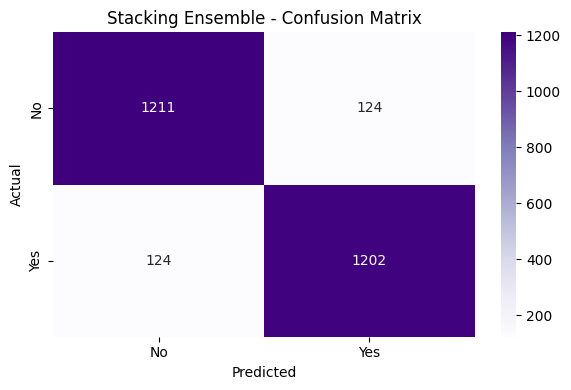

In [7]:
# Confusion matrix for stacking
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.title('Stacking Ensemble - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix_stack.png')
plt.show()

## Step 6 - Compare All 4 Models Together

In [8]:
# Load previous 3 model results from Notebook 03
prev_results = pd.read_csv('../outputs/results/model_comparison_table.csv',
                            index_col='Model')

# Add stacking results
stack_df    = pd.DataFrame([stack_results]).set_index('Model')
all_results = pd.concat([prev_results, stack_df])

print('=== All 4 Models Comparison ===')
print(all_results.to_string())

# Find best model
best = all_results['Accuracy'].idxmax()
print(f'\nBest model overall: {best}')
print(f'Accuracy          : {all_results.loc[best, "Accuracy"]*100:.2f}%')
print(f'AUC               : {all_results.loc[best, "AUC"]}')

=== All 4 Models Comparison ===
                   Accuracy  Precision  Recall  F1 Score     AUC
Model                                                           
Random Forest        0.9004     0.9047  0.8944    0.8995  0.9237
XGBoost              0.9000     0.9003  0.8989    0.8996  0.9216
CatBoost             0.9049     0.9049  0.9042    0.9046  0.9211
Stacking Ensemble    0.9068     0.9065  0.9065    0.9065  0.9250

Best model overall: Stacking Ensemble
Accuracy          : 90.68%
AUC               : 0.925


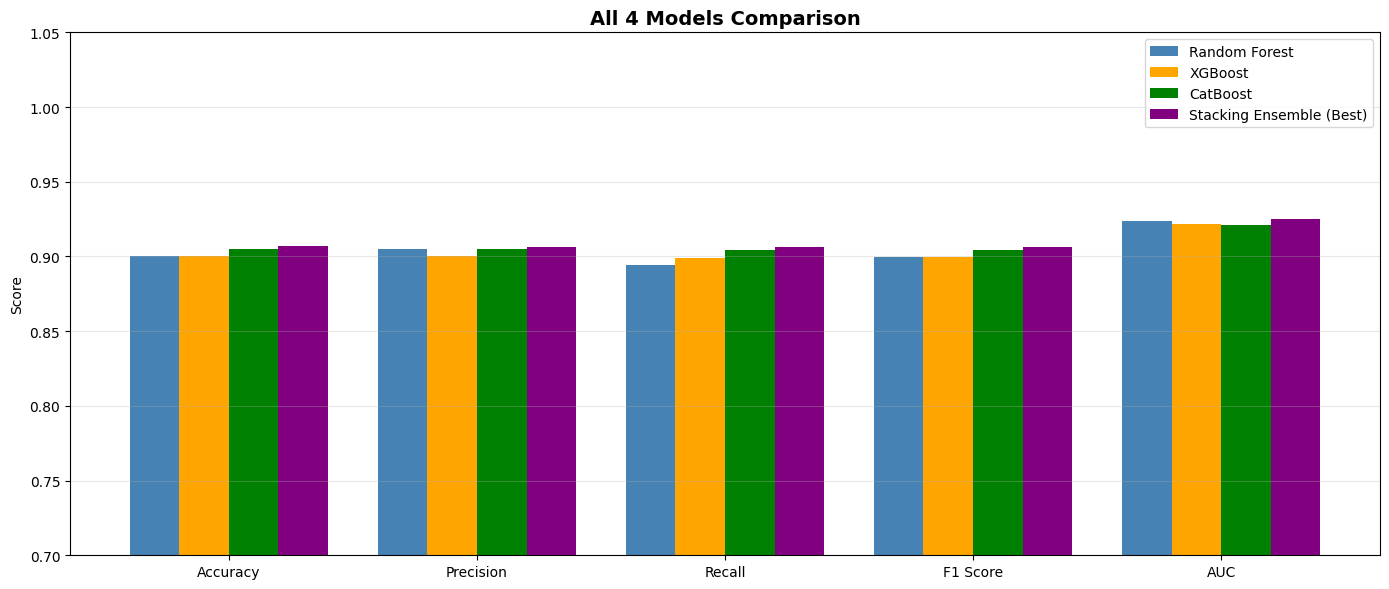

In [9]:
# Bar chart - compare all 4 models
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']
x       = np.arange(len(metrics))
width   = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width*1.5, all_results.loc['Random Forest'][metrics],    width,
       label='Random Forest',    color='steelblue')
ax.bar(x - width*0.5, all_results.loc['XGBoost'][metrics],          width,
       label='XGBoost',          color='orange')
ax.bar(x + width*0.5, all_results.loc['CatBoost'][metrics],         width,
       label='CatBoost',         color='green')
ax.bar(x + width*1.5, all_results.loc['Stacking Ensemble'][metrics],width,
       label='Stacking Ensemble (Best)', color='purple')

ax.set_title('All 4 Models Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0.7, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/all_models_comparison.png')
plt.show()

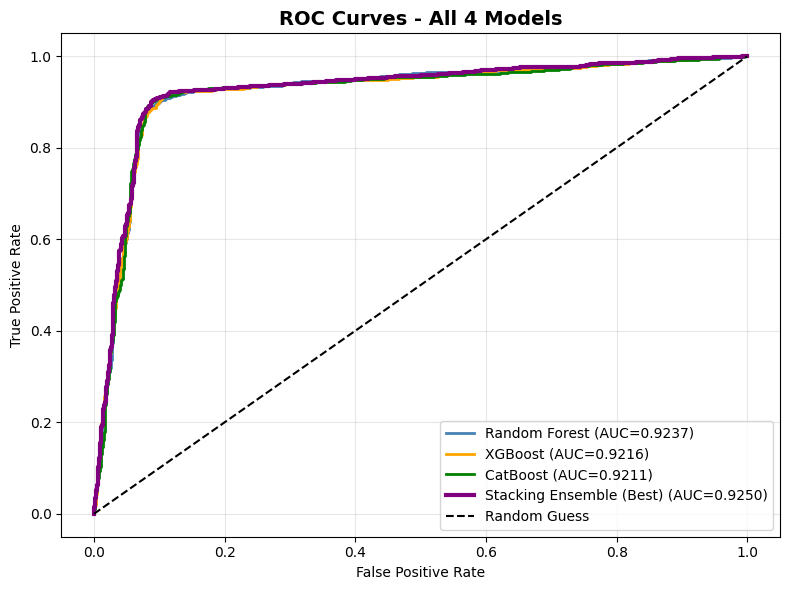

In [10]:
# ROC curves - all 4 models
plt.figure(figsize=(8, 6))

for model, name, color, lw in [
    (rf_model,       'Random Forest',           'steelblue', 2),
    (xgb_model,      'XGBoost',                 'orange',    2),
    (cat_model,      'CatBoost',                'green',     2),
    (stacking_model, 'Stacking Ensemble (Best)','purple',    3)
]:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})',
             color=color, linewidth=lw)

plt.plot([0,1],[0,1],'k--', label='Random Guess')
plt.title('ROC Curves - All 4 Models', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/roc_curves_all_models.png')
plt.show()

## Step 7 - Save Stacking Model and Results

In [11]:
# Save stacking model
joblib.dump(stacking_model, '../models/stacking_ensemble.pkl')
print('Stacking Ensemble model saved!')

# Save full comparison table
all_results.to_csv('../outputs/results/all_models_comparison.csv')
print('Full comparison table saved!')

# Final summary
print('\n=== FINAL SUMMARY ===')
print(all_results[['Accuracy', 'F1 Score', 'AUC']].to_string())
best = all_results['Accuracy'].idxmax()
print(f'\nBest Model : {best}')
print(f'Accuracy   : {all_results.loc[best, "Accuracy"]*100:.2f}%')
print(f'F1 Score   : {all_results.loc[best, "F1 Score"]}')
print(f'AUC        : {all_results.loc[best, "AUC"]}')

Stacking Ensemble model saved!
Full comparison table saved!

=== FINAL SUMMARY ===
                   Accuracy  F1 Score     AUC
Model                                        
Random Forest        0.9004    0.8995  0.9237
XGBoost              0.9000    0.8996  0.9216
CatBoost             0.9049    0.9046  0.9211
Stacking Ensemble    0.9068    0.9065  0.9250

Best Model : Stacking Ensemble
Accuracy   : 90.68%
F1 Score   : 0.9065
AUC        : 0.925
